In [1]:
%load_ext autoreload
%autoreload 2
import sys
from pathlib import Path
import numpy as np
import pandas as pd

sys.path.append("..")
from src import *

/home/vmorelli-iit.local/Projects/freq2clean/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Cupy Available= 1


# [Mouse Neuronal Populations ($100\mu m$)](https://zenodo.org/records/6299096)
This dataset comes from the training and validation open resources of *DeepCAD-RT*. 

Please download and extract it into `dataset/zenodo/mouse_neuronal_populations` using:
```sh
wget https://zenodo.org/records/6299096/files/05_MouseNeurons_GCaMP6f_100umdepth_50mWpower_30Hz_highSNR_MCRound1.tif?download=1
mv 05_MouseNeurons_GCaMP6f_100umdepth_50mWpower_30Hz_highSNR_MCRound1.tif?download=1 gt.tiff
wget https://zenodo.org/records/6299096/files/05_MouseNeurons_GCaMP6f_100umdepth_50mWpower_30Hz_lowSNR_MCRound1.tif?download=1
mv 05_MouseNeurons_GCaMP6f_100umdepth_50mWpower_30Hz_lowSNR_MCRound1.tif?download=1 x.tiff
```

In [3]:
meta=DATASETS["mouse_neuronal_populations"]
x_paths = sorted(meta.dir.glob("*.tif"))
cprint(*[f"rand:{_.name}" for _ in x_paths], sep="\n")

In [15]:
x = Recording(meta.x, max_frames=None)
gt = Recording(meta.gt, max_frames=None)

In [29]:
x.np.shape

(6500, 490, 490)

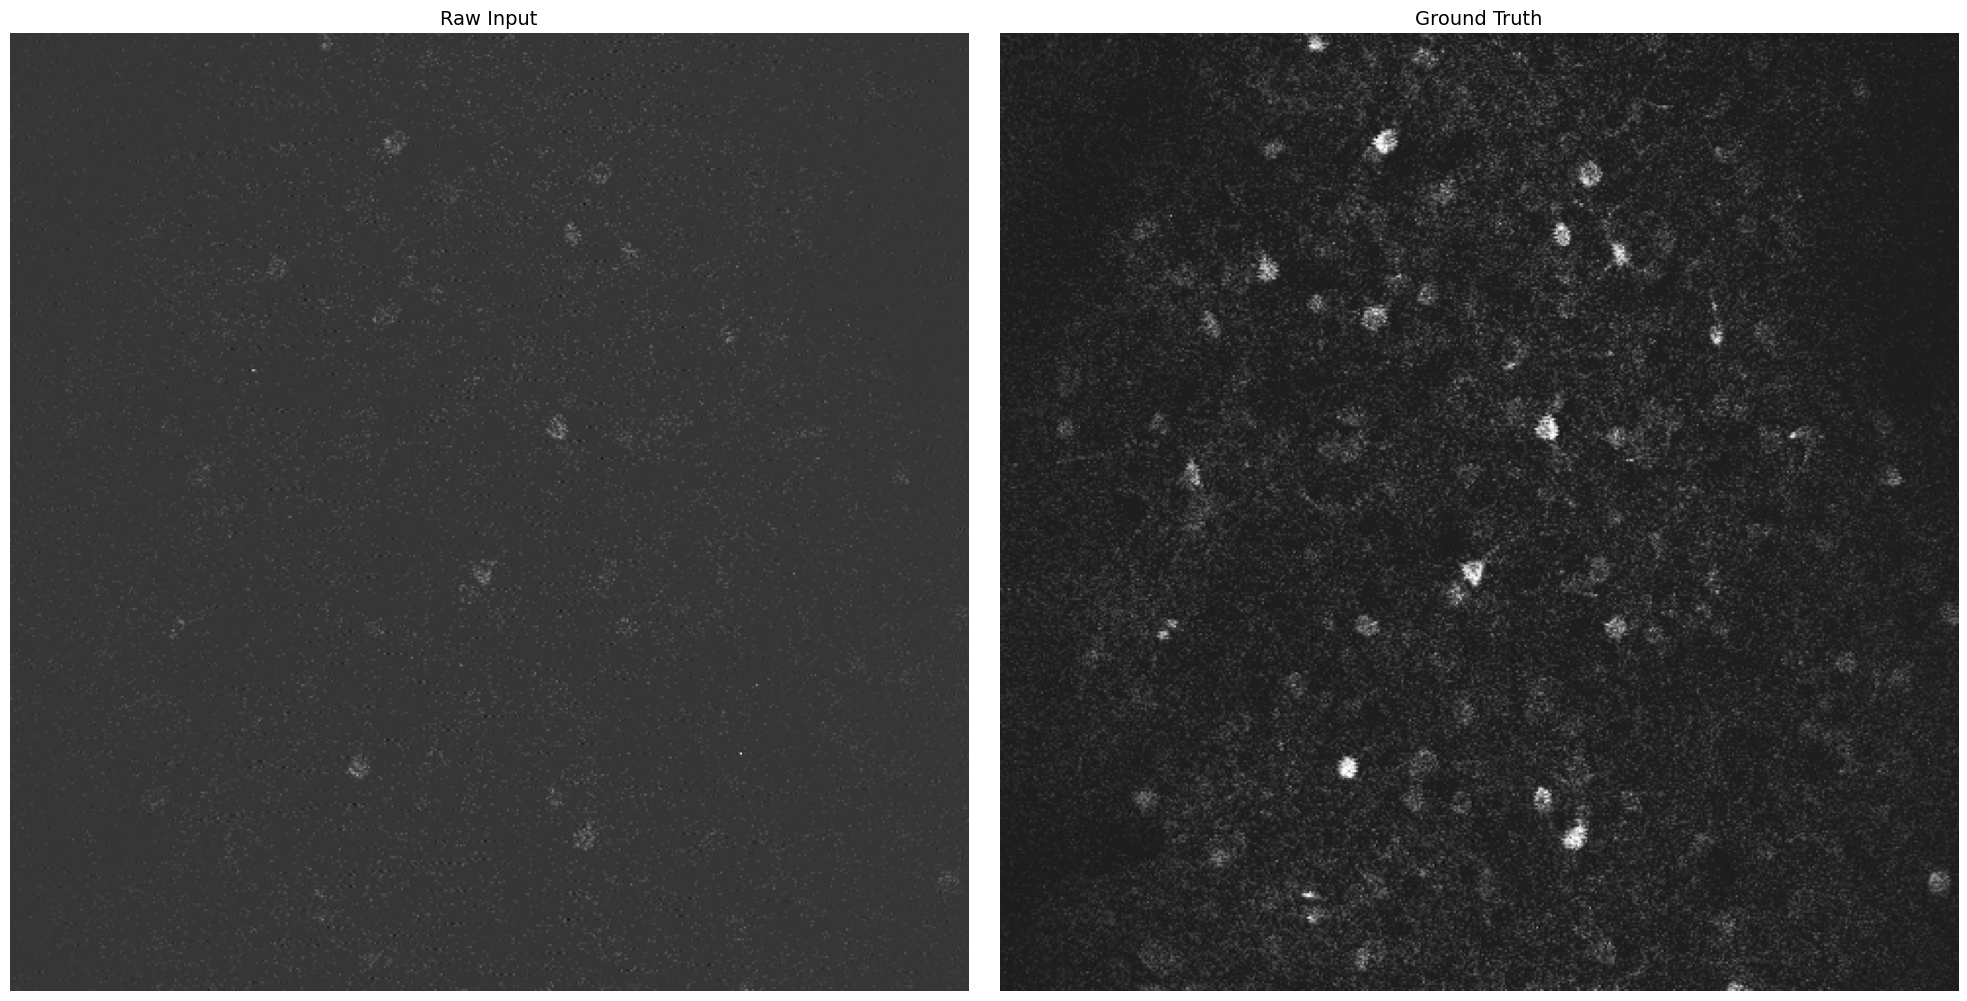

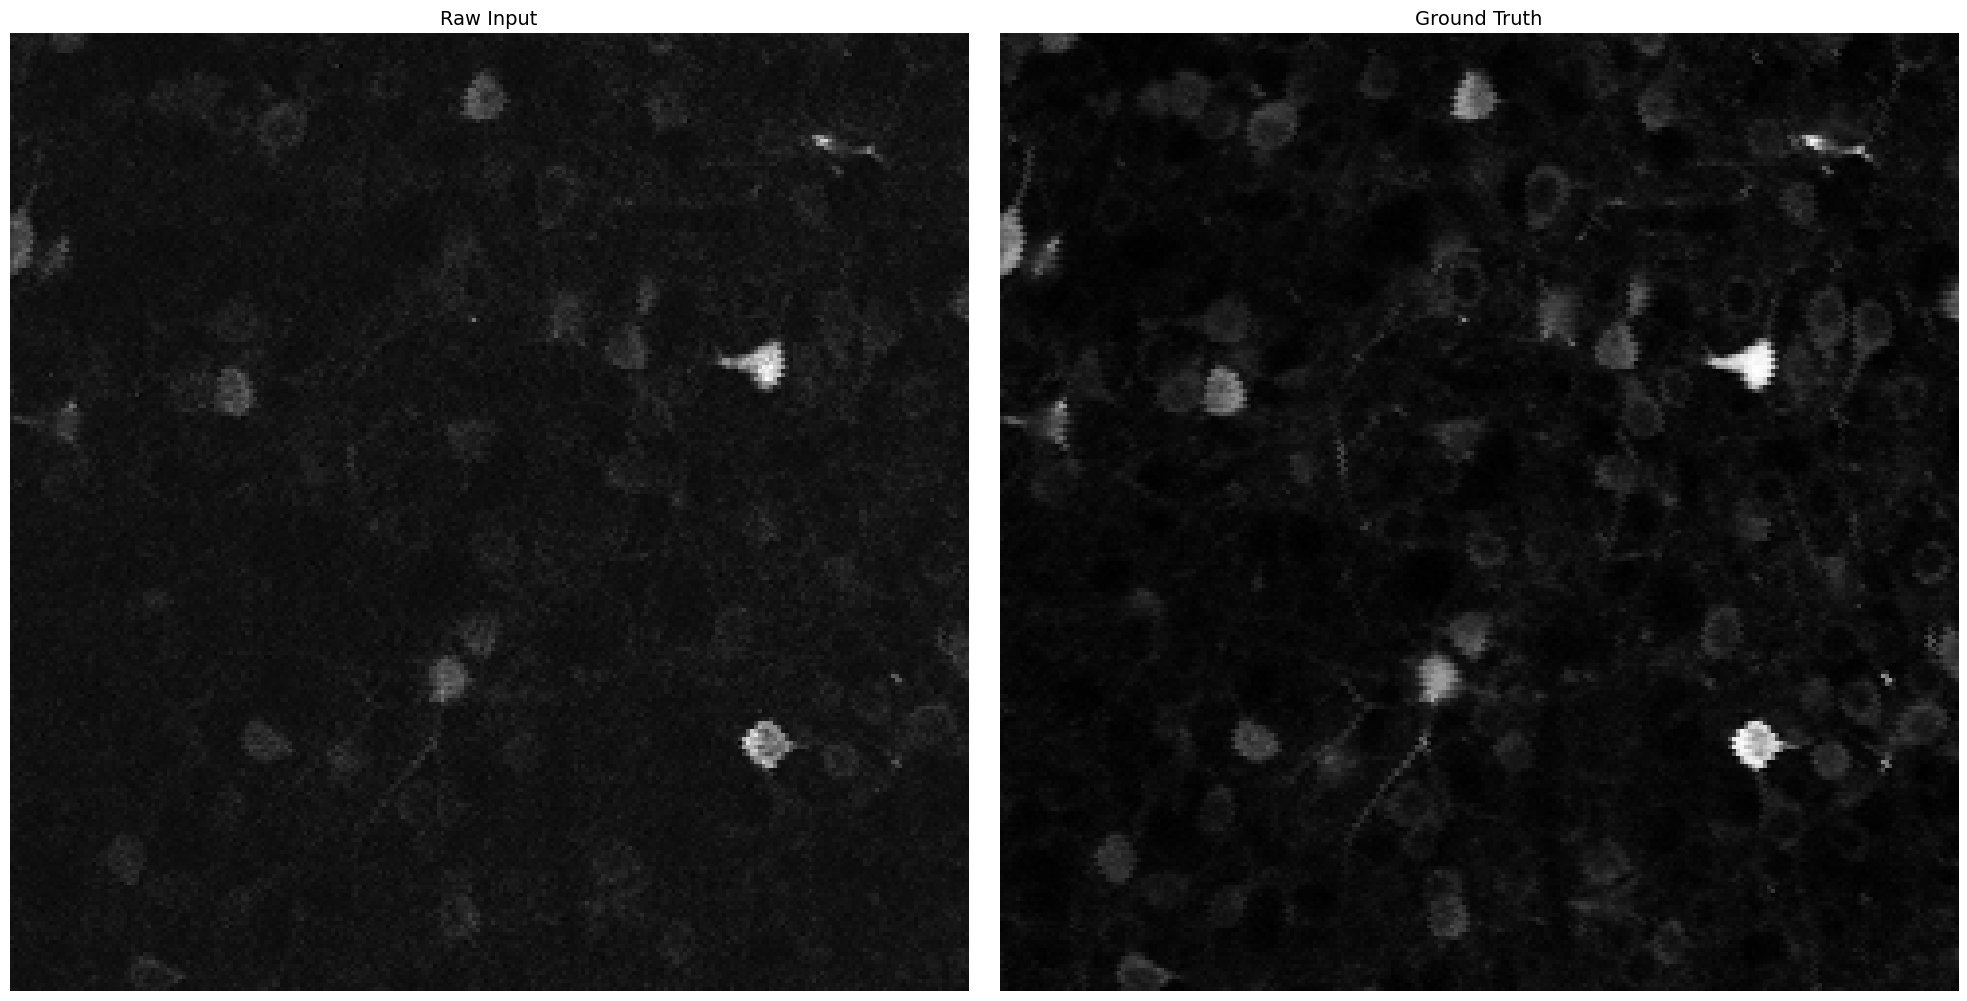

In [23]:
imshow({"Raw Input":x.np[-1], "Ground Truth": gt.np[-1]}, size=10)
imshow({"Raw Input":x.avg_frame(50,32), "Ground Truth": gt.avg_frame(50,32)}, size=10, zoom=2)

<Axes: >

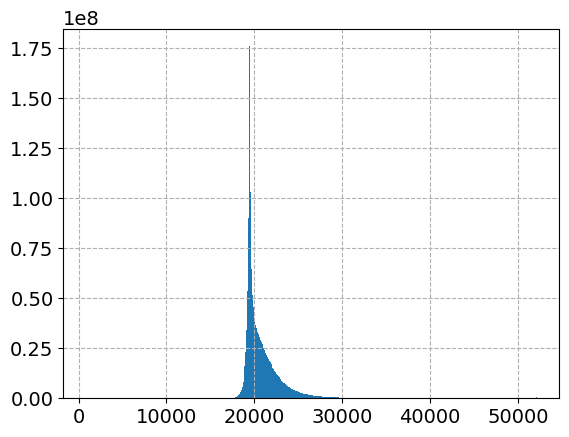

In [25]:
pd.Series(gt.np.ravel()).hist(bins=500)

In [26]:
np.quantile(gt.np, 0.999)

np.float64(47939.0)